# FinCast Prediction Quality Analysis

This notebook analyzes three different questions:

1. **Training and validation labels:** what is the class balance, per-ticker spread, and majority baseline?
2. **Validation behavior:** does the model beat the validation majority class, or does it mostly emit one label?
3. **Live prediction behavior:** how accurate are settled rows in `predictions_log.jsonl`, by ticker and by predicted/actual move?

A live prediction is scored only after `actual_move_bin` is available. Repeated predictions for the same ticker/date are reduced to the latest logged run.

In [45]:
import json
import math
import os
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
MOVE_BINS = ['strong_down', 'down', 'flat', 'up', 'strong_up']

def locate_base_dir():
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd / 'news_scraper', cwd / '..', cwd / '..' / '..']
    for candidate in candidates:
        candidate = candidate.resolve()
        if (candidate / 'data' / 'train_data' / 'combined').exists() and (candidate / 'predictions_log.jsonl').exists():
            return candidate
    raise FileNotFoundError(f'Could not locate news_scraper from {cwd}')

BASE_DIR = locate_base_dir()
TRAIN_PATH = BASE_DIR / 'data' / 'train_data' / 'combined' / 'train.jsonl'
VAL_PATH = BASE_DIR / 'data' / 'train_data' / 'combined' / 'val.jsonl'
PREDICTIONS_PATH = BASE_DIR / 'predictions_log.jsonl'
print('BASE_DIR:', BASE_DIR)
print('TRAIN_PATH:', TRAIN_PATH, 'exists=', TRAIN_PATH.exists())
print('VAL_PATH:', VAL_PATH, 'exists=', VAL_PATH.exists())
print('PREDICTIONS_PATH:', PREDICTIONS_PATH, 'exists=', PREDICTIONS_PATH.exists())

BASE_DIR: C:\work\PratyushMishraGitHub\news_analysis\news_scraper
TRAIN_PATH: C:\work\PratyushMishraGitHub\news_analysis\news_scraper\data\train_data\combined\train.jsonl exists= True
VAL_PATH: C:\work\PratyushMishraGitHub\news_analysis\news_scraper\data\train_data\combined\val.jsonl exists= True
PREDICTIONS_PATH: C:\work\PratyushMishraGitHub\news_analysis\news_scraper\predictions_log.jsonl exists= True


## 1. Load and normalize the three data sources

The training and validation files use chat records. The assistant message is the ground-truth `move_bin`. The prediction log contains model output, actual outcome, percentage change, and news count.

In [33]:
def read_jsonl(path):
    rows = []
    with open(path, 'r', encoding='utf-8') as fh:
        for line_number, line in enumerate(fh, 1):
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError as exc:
                print(f'Skipping invalid JSON at {path}:{line_number}: {exc}')
    return rows

def extract_move_bin_from_record(record):
    messages = record.get('messages', [])
    if len(messages) < 3:
        return None
    try:
        payload = json.loads(messages[-1].get('content', '{}'))
    except (TypeError, json.JSONDecodeError):
        return None
    value = payload.get('move_bin')
    return value if value in MOVE_BINS else None

def extract_ticker_from_record(record):
    meta = record.get('_meta', {})
    if meta.get('ticker'):
        return str(meta['ticker']).upper()
    user_content = '\n'.join(str(message.get('content', '')) for message in record.get('messages', []) if message.get('role') == 'user')
    match = re.search(r'(?:^|\n)Ticker:\s*([A-Za-z0-9_.-]+)', user_content)
    return match.group(1).upper() if match else 'UNKNOWN'

def records_to_frame(records, split_name):
    rows = []
    for index, record in enumerate(records):
        rows.append({
            'row_id': index,
            'split': split_name,
            'ticker': extract_ticker_from_record(record),
            'date': record.get('_meta', {}).get('date'),
            'label': extract_move_bin_from_record(record),
        })
    return pd.DataFrame(rows)

train_df = records_to_frame(read_jsonl(TRAIN_PATH), 'train')
val_df = records_to_frame(read_jsonl(VAL_PATH), 'validation')
train_val_df = pd.concat([train_df, val_df], ignore_index=True)

prediction_rows = read_jsonl(PREDICTIONS_PATH)
pred_df = pd.DataFrame(prediction_rows)
if not pred_df.empty:
    pred_df['logged_at'] = pd.to_datetime(pred_df.get('logged_at'), errors='coerce', utc=True)
    pred_df['date'] = pd.to_datetime(pred_df.get('date'), errors='coerce')
    for column in ['predicted_move_bin', 'actual_move_bin']:
        if column in pred_df:
            pred_df[column] = pred_df[column].astype('string')
    pred_df['ticker'] = pred_df['ticker'].astype('string').str.upper()
    pred_df['actual_change_1d'] = pd.to_numeric(pred_df.get('actual_change_1d'), errors='coerce')
    pred_df['num_news_items'] = pd.to_numeric(pred_df.get('num_news_items'), errors='coerce')
    pred_df['settled'] = pred_df['actual_move_bin'].isin(MOVE_BINS)
    pred_df = pred_df.sort_values('logged_at').drop_duplicates(['ticker', 'date'], keep='last').reset_index(drop=True)

print(f'Train rows: {len(train_df):,}; validation rows: {len(val_df):,}')
print(f'Prediction log rows after latest-run deduplication: {len(pred_df):,}')
if not pred_df.empty:
    print(f'Settled prediction rows: {pred_df["settled"].sum():,}; unsettled: {(~pred_df["settled"]).sum():,}')
display(train_val_df.head())
display(pred_df.head())

Train rows: 1,068; validation rows: 157
Prediction log rows after latest-run deduplication: 74
Settled prediction rows: 58; unsettled: 16


,row_id,split,ticker,date,label
0,0,train,AAPL,None,up
1,1,train,AAPL,None,down
2,2,train,AAPL,None,flat
3,3,train,AAPL,None,up
4,4,train,AAPL,None,flat


,logged_at,ticker,date,predicted_move_bin,raw_model_output,num_news_items,base_price,model_id,adapter_path,actual_move_bin,actual_change_1d,correct,settled
0,2026-07-31 06:35:13.253303+00:00,AAPL,2026-07-29,up,"{""move_bin"": ""up""}",4,338.19,microsoft/Phi-3-mini-4k-instruct,C:\work\PratyushMishraGitHub\news_analysis\fin...,down,-1.4075,False,True
1,2026-07-31 06:35:15.256372+00:00,AMD,2026-07-29,strong_down,"{""move_bin"": ""strong_down""}",4,429.56,microsoft/Phi-3-mini-4k-instruct,C:\work\PratyushMishraGitHub\news_analysis\fin...,strong_up,12.9970,False,True
2,2026-07-31 06:35:16.723955+00:00,AMZN,2026-07-29,flat,"{""move_bin"": ""flat""}",4,226.65,microsoft/Phi-3-mini-4k-instruct,C:\work\PratyushMishraGitHub\news_analysis\fin...,strong_up,3.9047,False,True
3,2026-07-31 06:35:18.109773+00:00,BOTZ,2026-07-29,up,"{""move_bin"": ""up""}",1,33.68,microsoft/Phi-3-mini-4k-instruct,C:\work\PratyushMishraGitHub\news_analysis\fin...,strong_up,3.6223,False,True
4,2026-07-31 06:35:19.561103+00:00,DRIV,2026-07-29,strong_down,"{""move_bin"": ""strong_down""}",1,31.96,microsoft/Phi-3-mini-4k-instruct,C:\work\PratyushMishraGitHub\news_analysis\fin...,strong_up,4.5369,False,True


## 2. Train versus validation label distribution

A model that predicts the most common class can look competent when the labels are imbalanced. This section shows the class spread overall and by ticker, then compares validation accuracy against that real validation majority baseline.

,train_count,train_share_pct,validation_count,validation_share_pct
label,,,,
strong_down,134,12.55,13,8.28
down,219,20.51,22,14.01
flat,295,27.62,49,31.21
up,232,21.72,42,26.75
strong_up,188,17.60,31,19.75


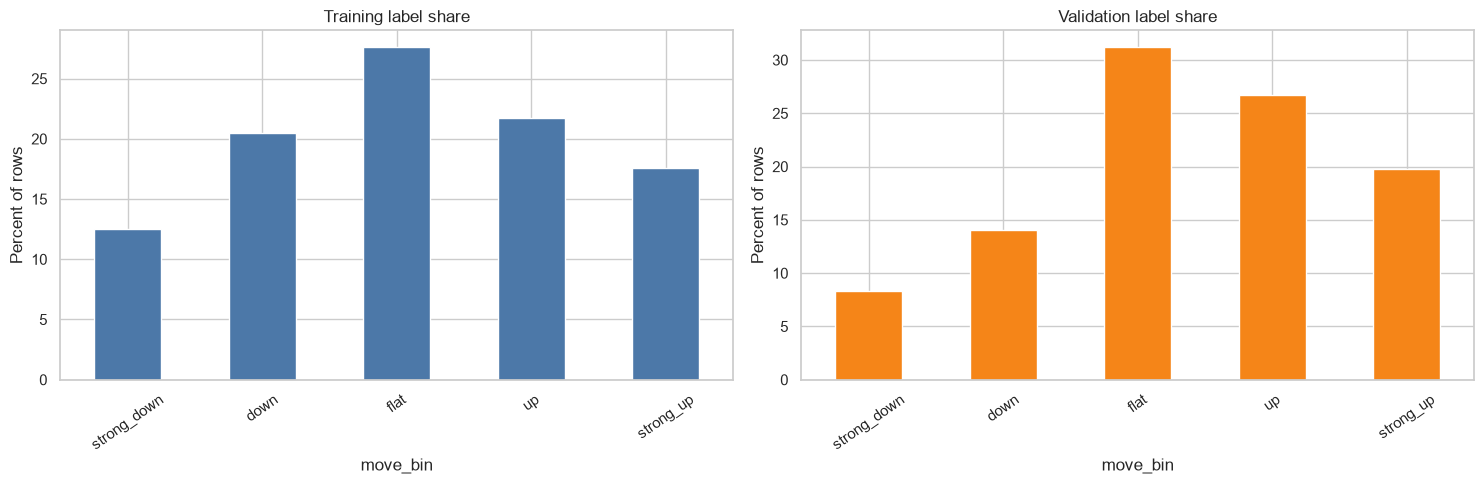

,split,ticker,label,share_pct
2,train,AAPL,down,23.809524
1,train,AAPL,flat,28.571429
4,train,AAPL,strong_down,6.349206
3,train,AAPL,strong_up,11.111111
0,train,AAPL,up,30.158730
...,...,...,...,...
160,validation,XLK,up,25.000000
162,validation,XLV,down,28.571429
161,validation,XLV,flat,42.857143
163,validation,XLV,strong_up,14.285714


In [34]:
def distribution_table(frame, label_column='label'):
    counts = frame[label_column].value_counts().reindex(MOVE_BINS, fill_value=0)
    result = pd.DataFrame({'count': counts, 'share_pct': (counts / max(len(frame), 1) * 100).round(2)})
    return result

train_dist = distribution_table(train_df)
val_dist = distribution_table(val_df)
distribution_comparison = train_dist[['count', 'share_pct']].add_prefix('train_').join(
    val_dist[['count', 'share_pct']].add_prefix('validation_')
)
display(distribution_comparison)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
train_dist['share_pct'].plot(kind='bar', ax=axes[0], color='#4c78a8', title='Training label share')
val_dist['share_pct'].plot(kind='bar', ax=axes[1], color='#f58518', title='Validation label share')
for ax in axes:
    ax.set_xlabel('move_bin')
    ax.set_ylabel('Percent of rows')
    ax.tick_params(axis='x', rotation=35)
plt.tight_layout(); plt.show()

ticker_label_share = (
    train_val_df.dropna(subset=['label'])
    .groupby(['split', 'ticker'])['label']
    .value_counts(normalize=True)
    .mul(100).rename('share_pct').reset_index()
)
display(ticker_label_share.sort_values(['split', 'ticker', 'label']))

## 3. Train versus validation versus production predictions

The label files alone show what the model was asked to learn; they do not show whether it fit the training examples. For a complete diagnosis, generate deterministic model predictions on both `train.jsonl` and `val.jsonl`, then compare:

- **Train predictions:** fit/memorization. High train accuracy with much lower validation accuracy indicates overfitting.
- **Validation predictions:** generalization during model development. In this project, validation loss is used for checkpoint selection and early stopping, so validation is informative but is not an untouched final test set.
- **Settled `predictions_log.jsonl`:** post-training production behavior after actual outcomes are reconciled. This is currently the strongest real-world check, although the sample is smaller and time-correlated.

The notebook currently loads `eval_predictions.jsonl` when available for validation predictions. Add a matching deterministic train evaluation output before making claims about train-versus-validation fit. A future chronological holdout or walk-forward evaluation should be reserved for the final model decision.

A prediction stream dominated by one class, especially when it is close to the relevant majority baseline, is evidence of collapse toward a maximum-signal strategy.

In [46]:
input_status = pd.DataFrame({
    'file': ['train.jsonl', 'val.jsonl', 'predictions_log.jsonl'],
    'path': [str(TRAIN_PATH), str(VAL_PATH), str(PREDICTIONS_PATH)],
    'exists': [TRAIN_PATH.exists(), VAL_PATH.exists(), PREDICTIONS_PATH.exists()],
    'rows_loaded': [len(train_df), len(val_df), len(pred_df)],
})
display(input_status)

print('Evaluation design:')
print('- train.jsonl and val.jsonl provide the labels used during model training and checkpoint selection.')
print('- predictions_log.jsonl provides production predicted_move_bin and reconciled actual_move_bin values.')
print('- Production accuracy is calculated only from settled prediction-log rows.')
print('- No separate validation prediction file is expected or required.')

print('\nLabel distributions:')
display(distribution_comparison)

,file,path,exists,rows_loaded
0,train.jsonl,C:\work\PratyushMishraGitHub\news_analysis\new...,True,1068
1,val.jsonl,C:\work\PratyushMishraGitHub\news_analysis\new...,True,157
2,predictions_log.jsonl,C:\work\PratyushMishraGitHub\news_analysis\new...,True,74


Evaluation design:
- train.jsonl and val.jsonl provide the labels used during model training and checkpoint selection.
- predictions_log.jsonl provides production predicted_move_bin and reconciled actual_move_bin values.
- Production accuracy is calculated only from settled prediction-log rows.
- No separate validation prediction file is expected or required.

Label distributions:


,train_count,train_share_pct,validation_count,validation_share_pct
label,,,,
strong_down,134,12.55,13,8.28
down,219,20.51,22,14.01
flat,295,27.62,49,31.21
up,232,21.72,42,26.75
strong_up,188,17.60,31,19.75


## 4. Training versus validation labels by ticker

Validation was part of model development, so this section checks whether train and validation have similar ticker coverage and label distributions. It does not claim model accuracy for validation; actual predicted-versus-actual accuracy comes from the settled production log.

,train_n,train_mode,train_mode_share_pct,train_strong_down_pct,train_down_pct,train_flat_pct,train_up_pct,train_strong_up_pct,validation_n,validation_mode,validation_mode_share_pct,validation_strong_down_pct,validation_down_pct,validation_flat_pct,validation_up_pct,validation_strong_up_pct
ticker,,,,,,,,,,,,,,,,
AAPL,63,up,30.16,6.35,23.81,28.57,30.16,11.11,9,flat,33.33,11.11,11.11,33.33,33.33,11.11
AMD,48,strong_up,41.67,20.83,18.75,8.33,10.42,41.67,6,up,50.00,33.33,0.00,0.00,50.00,16.67
AMZN,63,up,26.98,15.87,14.29,22.22,26.98,20.63,9,up,44.44,0.00,33.33,0.00,44.44,22.22
BOTZ,18,up,38.89,16.67,22.22,16.67,38.89,5.56,8,up,37.50,0.00,25.00,25.00,37.50,12.50
DRIV,45,down,31.11,13.33,31.11,15.56,17.78,22.22,7,down,28.57,0.00,28.57,28.57,14.29,28.57
GOOGL,56,flat,30.36,17.86,21.43,30.36,19.64,10.71,9,flat,33.33,11.11,11.11,33.33,33.33,11.11
INTC,54,strong_up,48.15,25.93,9.26,7.41,9.26,48.15,9,strong_down,44.44,44.44,0.00,0.00,11.11,44.44
META,71,flat,32.39,19.72,16.90,32.39,14.08,16.90,9,flat,33.33,0.00,11.11,33.33,22.22,33.33
MSFT,65,down,35.38,13.85,35.38,16.92,15.38,18.46,9,flat,44.44,0.00,0.00,44.44,22.22,33.33


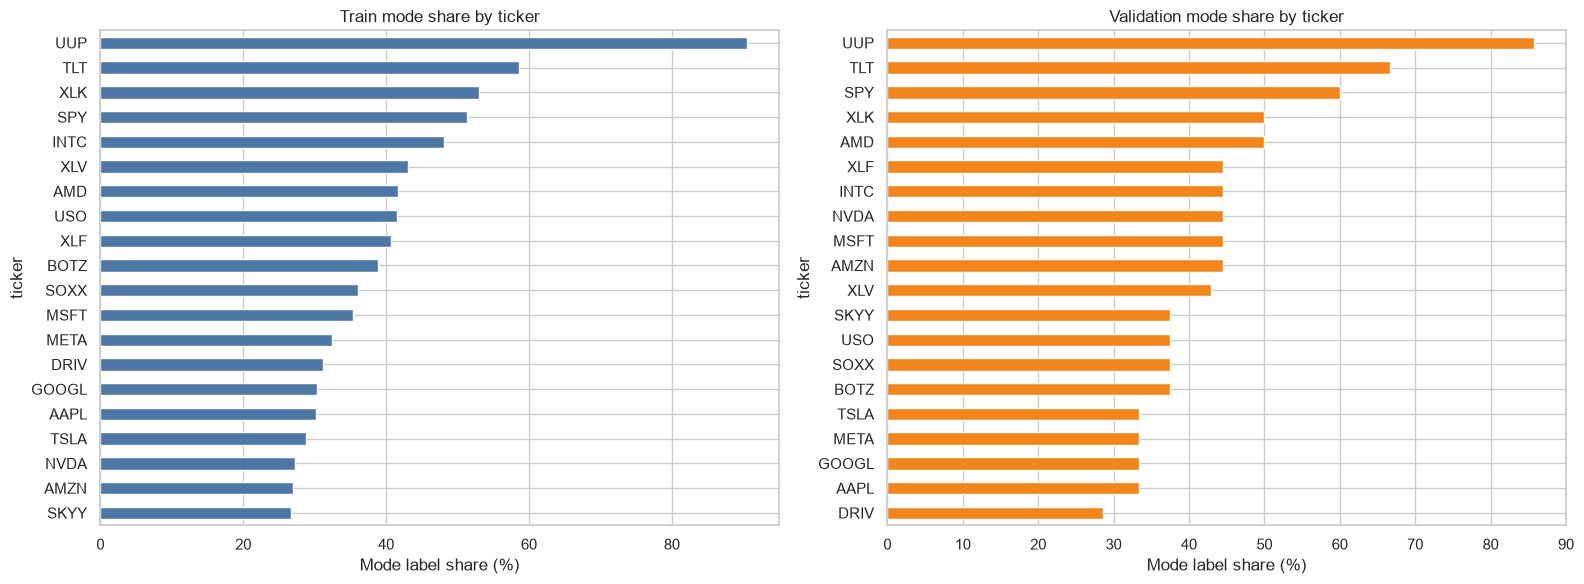

In [47]:
def ticker_split_metrics(group):
    counts = group['label'].value_counts().reindex(MOVE_BINS, fill_value=0)
    mode = counts.idxmax() if counts.sum() else 'unavailable'
    return pd.Series({
        'n': len(group),
        'mode': mode,
        'mode_share_pct': counts.max() / max(counts.sum(), 1) * 100,
        'strong_down_pct': counts['strong_down'] / max(counts.sum(), 1) * 100,
        'down_pct': counts['down'] / max(counts.sum(), 1) * 100,
        'flat_pct': counts['flat'] / max(counts.sum(), 1) * 100,
        'up_pct': counts['up'] / max(counts.sum(), 1) * 100,
        'strong_up_pct': counts['strong_up'] / max(counts.sum(), 1) * 100,
    })

train_ticker = train_df.groupby('ticker').apply(ticker_split_metrics, include_groups=False).add_prefix('train_')
val_ticker = val_df.groupby('ticker').apply(ticker_split_metrics, include_groups=False).add_prefix('validation_')
ticker_split_comparison = train_ticker.join(val_ticker, how='outer')
display(ticker_split_comparison.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
train_ticker['train_mode_share_pct'].sort_values().plot(kind='barh', ax=axes[0], color='#4c78a8', title='Train mode share by ticker')
val_ticker['validation_mode_share_pct'].sort_values().plot(kind='barh', ax=axes[1], color='#f58518', title='Validation mode share by ticker')
for ax in axes:
    ax.set_xlabel('Mode label share (%)')
plt.tight_layout(); plt.show()

## 5. Live prediction accuracy after outcomes settle

This section uses only rows with a valid `actual_move_bin`. It reports exact five-class accuracy and directional accuracy, where down classes are negative, flat is neutral, and up classes are positive.

,value
settled_rows,58
exact_five_class_accuracy_pct,25.862069
direction_accuracy_pct,51.724138
always_actual_mode_baseline_pct,48.275862
lift_over_actual_mode_points,-22.413793
actual_mode,strong_up
prediction_mode,up
prediction_mode_share_pct,44.827586
prediction_entropy_bits,1.963487


predicted_move_bin,strong_down,down,flat,up,strong_up
actual_move_bin,,,,,
strong_down,2,0,1,0,1
down,0,0,2,4,2
flat,0,1,1,5,0
up,1,0,2,5,3
strong_up,3,1,5,12,7


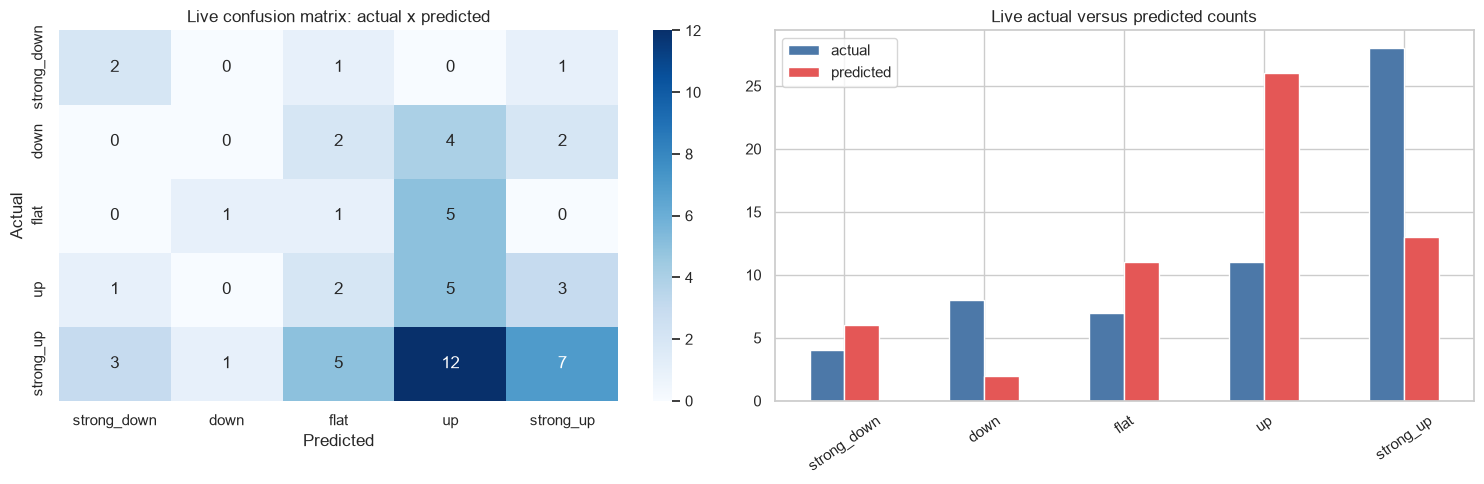

In [37]:
def direction_label(value):
    if value in ['strong_down', 'down']:
        return 'down'
    if value == 'flat':
        return 'flat'
    if value in ['up', 'strong_up']:
        return 'up'
    return None

settled_df = pred_df[pred_df['settled']].copy() if not pred_df.empty else pd.DataFrame()
if not settled_df.empty:
    settled_df['correct'] = settled_df['predicted_move_bin'] == settled_df['actual_move_bin']
    settled_df['predicted_direction'] = settled_df['predicted_move_bin'].map(direction_label)
    settled_df['actual_direction'] = settled_df['actual_move_bin'].map(direction_label)
    settled_df['direction_correct'] = settled_df['predicted_direction'] == settled_df['actual_direction']
    live_mode_accuracy, live_mode = majority_accuracy(settled_df['actual_move_bin'])
    live_summary = pd.Series({
        'settled_rows': len(settled_df),
        'exact_five_class_accuracy_pct': settled_df['correct'].mean() * 100,
        'direction_accuracy_pct': settled_df['direction_correct'].mean() * 100,
        'always_actual_mode_baseline_pct': live_mode_accuracy * 100,
        'lift_over_actual_mode_points': (settled_df['correct'].mean() - live_mode_accuracy) * 100,
        'actual_mode': live_mode,
        'prediction_mode': settled_df['predicted_move_bin'].mode().iloc[0],
        'prediction_mode_share_pct': settled_df['predicted_move_bin'].value_counts(normalize=True).iloc[0] * 100,
        'prediction_entropy_bits': entropy_from_counts(settled_df['predicted_move_bin'].value_counts().reindex(MOVE_BINS, fill_value=0)),
    })
    display(live_summary.to_frame('value'))
    live_confusion = pd.crosstab(settled_df['actual_move_bin'], settled_df['predicted_move_bin']).reindex(index=MOVE_BINS, columns=MOVE_BINS, fill_value=0)
    display(live_confusion.style.background_gradient(cmap='Blues'))

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.heatmap(live_confusion, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title('Live confusion matrix: actual x predicted')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
    pd.DataFrame({
        'actual': settled_df['actual_move_bin'].value_counts().reindex(MOVE_BINS, fill_value=0),
        'predicted': settled_df['predicted_move_bin'].value_counts().reindex(MOVE_BINS, fill_value=0),
    }).plot(kind='bar', ax=axes[1], color=['#4c78a8', '#e45756'], title='Live actual versus predicted counts')
    axes[1].tick_params(axis='x', rotation=35)
    plt.tight_layout(); plt.show()
else:
    print('No settled live predictions are available yet.')

## 6. Slice and dice live quality by ticker

The spread columns show how outcomes differ by ticker: mean and median return, return volatility, worst/best move, exact accuracy, directional accuracy, and prediction concentration.

,n,exact_accuracy_pct,direction_accuracy_pct,actual_mode,actual_mode_share_pct,prediction_mode,prediction_mode_share_pct,mean_actual_change_pct,median_actual_change_pct,std_actual_change_pct,min_actual_change_pct,max_actual_change_pct,mean_news_items
ticker,,,,,,,,,,,,,
MSFT,3,66.667,100.000,strong_up,100.000,strong_up,66.667,10.220,10.220,7.476,4.934,15.507,1.667
XLF,3,66.667,100.000,up,66.667,up,100.000,0.669,0.669,0.147,0.565,0.773,1.333
TSLA,2,50.000,100.000,strong_up,100.000,strong_up,50.000,3.193,3.193,0.477,2.856,3.530,2.000
INTC,2,50.000,100.000,up,50.000,strong_up,50.000,-1.299,-1.299,3.092,-3.485,0.887,1.000
SOXX,3,33.333,33.333,strong_up,66.667,strong_up,66.667,3.292,3.292,7.367,-1.918,8.501,1.000
AMZN,3,33.333,66.667,strong_up,66.667,strong_up,66.667,3.358,3.905,1.569,1.588,4.581,2.000
USO,3,33.333,33.333,down,33.333,strong_down,66.667,-1.740,-1.415,3.567,-5.458,1.653,1.667
SKYY,3,33.333,66.667,up,33.333,up,100.000,1.607,1.061,1.670,0.279,3.482,2.000
DRIV,3,33.333,66.667,strong_up,66.667,up,66.667,2.987,2.987,2.192,1.437,4.537,1.000


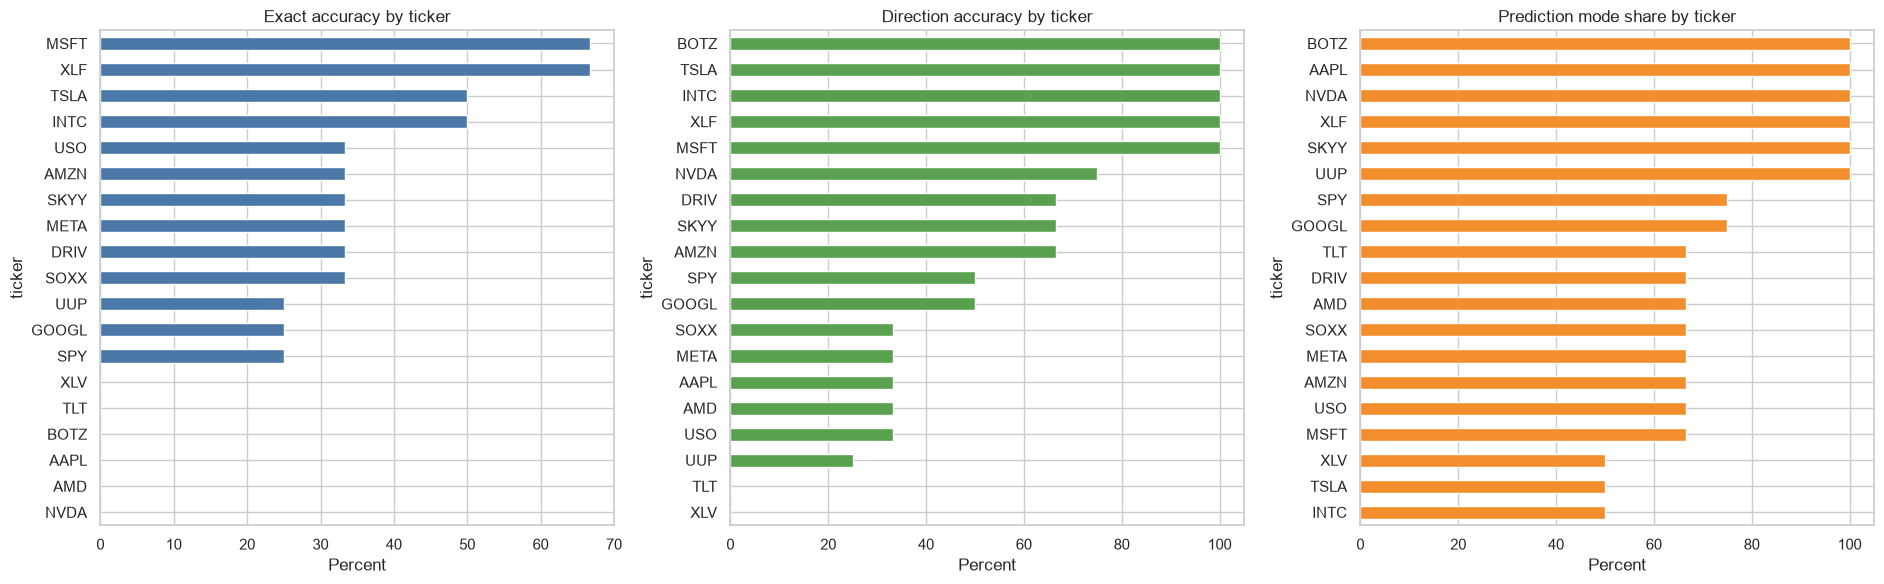

In [38]:
if not settled_df.empty:
    def ticker_live_metrics(group):
        actual_counts = group['actual_move_bin'].value_counts()
        prediction_counts = group['predicted_move_bin'].value_counts()
        actual_mode_share = actual_counts.iloc[0] / len(group)
        prediction_mode_share = prediction_counts.iloc[0] / len(group)
        return pd.Series({
            'n': len(group),
            'exact_accuracy_pct': group['correct'].mean() * 100,
            'direction_accuracy_pct': group['direction_correct'].mean() * 100,
            'actual_mode': actual_counts.index[0],
            'actual_mode_share_pct': actual_mode_share * 100,
            'prediction_mode': prediction_counts.index[0],
            'prediction_mode_share_pct': prediction_mode_share * 100,
            'mean_actual_change_pct': group['actual_change_1d'].mean(),
            'median_actual_change_pct': group['actual_change_1d'].median(),
            'std_actual_change_pct': group['actual_change_1d'].std(),
            'min_actual_change_pct': group['actual_change_1d'].min(),
            'max_actual_change_pct': group['actual_change_1d'].max(),
            'mean_news_items': group['num_news_items'].mean(),
        })

    ticker_live = settled_df.groupby('ticker').apply(ticker_live_metrics, include_groups=False).sort_values('exact_accuracy_pct', ascending=False)
    display(ticker_live.round(3))
    
    fig, axes = plt.subplots(1, 3, figsize=(19, 6))
    ticker_live['exact_accuracy_pct'].sort_values().plot(kind='barh', ax=axes[0], color='#4c78a8', title='Exact accuracy by ticker')
    ticker_live['direction_accuracy_pct'].sort_values().plot(kind='barh', ax=axes[1], color='#59a14f', title='Direction accuracy by ticker')
    ticker_live['prediction_mode_share_pct'].sort_values().plot(kind='barh', ax=axes[2], color='#f28e2b', title='Prediction mode share by ticker')
    for ax in axes:
        ax.set_xlabel('Percent')
    plt.tight_layout(); plt.show()
else:
    print('No settled live predictions are available yet.')

## 7. How far off are the predictions?

There are two useful notions of error:

- **Class distance:** `strong_down` versus `down` is one step off; `strong_down` versus `strong_up` is four steps off.
- **Economic miss:** compare the actual one-day percentage return with the typical return associated with the predicted class in the training data. This is descriptive, not a claim that the class has a fixed return.

The class-distance view is available for every settled row. The return view uses the training distribution as a reference only.

,value
mean_class_error_steps,1.259
median_class_error_steps,1.000
within_one_class_step_pct,68.966
opposite_direction_pct,48.276
mean_absolute_return_miss_vs_predicted_class_median,3.076


,count,mean,median,std
actual_move_bin,,,,
strong_down,4,-5.108,-4.496,2.108
down,8,-1.358,-1.411,0.415
flat,7,0.104,0.235,0.283
up,11,1.290,1.424,0.408
strong_up,17,5.324,3.905,3.692


n  mean_actual_change_pct  \
actual_move_bin predicted_move_bin                               
strong_up       up                  12                   4.810   
                strong_up            7                   4.790   
up              up                   5                   1.102   
strong_up       flat                 5                   3.905   
flat            up                   5                   0.184   
down            up                   4                  -1.431   
up              strong_up            3                   1.419   
strong_up       strong_down          3                   8.678   
down            strong_up            2                  -1.666   
                flat                 2                  -0.901   
up              flat                 2                   1.386   
strong_down     strong_down          2                  -4.472   
strong_up       down                 1                   2.946   
flat            flat                 1                   0.000   
                down                 1                  -0.191   
strong_down     strong_up            1                  -3.534   
                flat                 1                  -7.954   
up              strong_down          1                   1.653   

                                    median_actual_change_pct  \
actual_move_bin predicted_move_bin                             
strong_up       up                                     2.934   
                strong_up                              4.880   
up              up                                     1.061   
strong_up       flat                                   3.905   
flat            up                                     0.279   
down            up                                    -1.522   
up              strong_up                              1.588   
strong_up       strong_down                            8.501   
down            strong_up                             -1.666   
                flat                                  -0.901   
up              flat                                   1.386   
strong_down     strong_down                           -4.472   
strong_up       down                                   2.946   
flat            flat                                   0.000   
                down                                  -0.191   
strong_down     strong_up                             -3.534   
                flat                                  -7.954   
up              strong_down                            1.653   

                                    mean_class_error_steps  
actual_move_bin predicted_move_bin                          
strong_up       up                                     1.0  
                strong_up                              0.0  
up              up                                     0.0  
strong_up       flat                                   2.0  
flat            up                                     1.0  
down            up                                     2.0  
up              strong_up                              1.0  
strong_up       strong_down                            4.0  
down            strong_up                              3.0  
                flat                                   1.0  
up              flat                                   1.0  
strong_down     strong_down                            0.0  
strong_up       down                                   3.0  
flat            flat                                   0.0  
                down                                   1.0  
strong_down     strong_up                              4.0  
                flat                                   2.0  
up              strong_down                            3.0

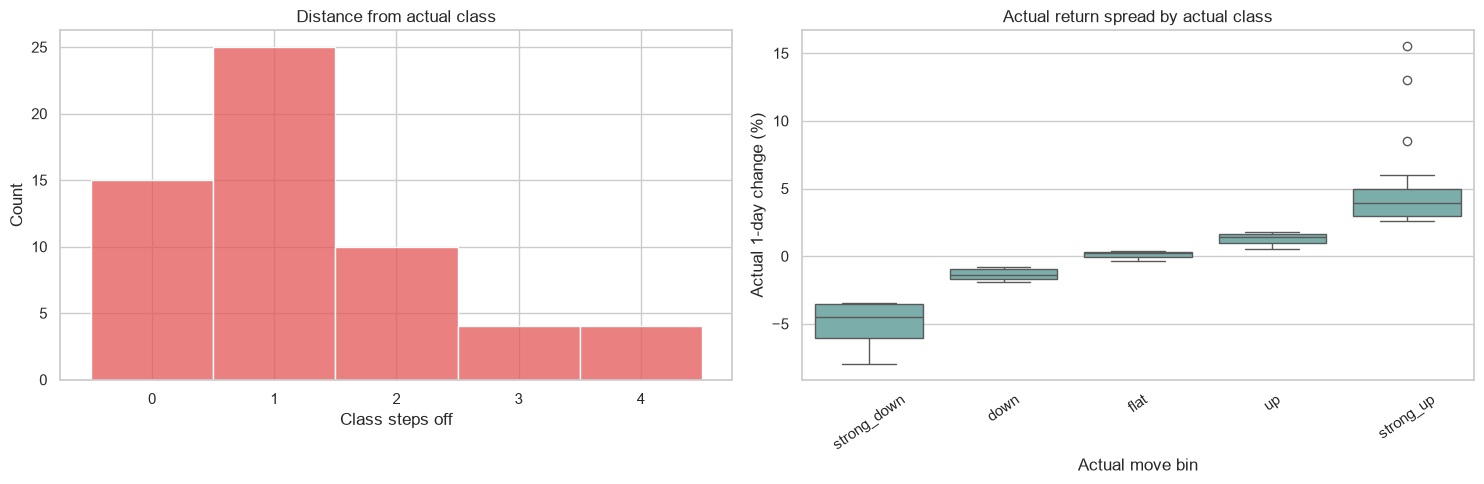

In [39]:
if not settled_df.empty:
    bin_position = {label: index for index, label in enumerate(MOVE_BINS)}
    settled_df['class_error_steps'] = (
        settled_df['predicted_move_bin'].map(bin_position) - settled_df['actual_move_bin'].map(bin_position)
    ).abs()
    settled_df['signed_class_error_steps'] = (
        settled_df['predicted_move_bin'].map(bin_position) - settled_df['actual_move_bin'].map(bin_position)
    )
    train_change_reference = train_val_df.copy()
    train_change_reference['change_1d'] = np.nan
    # The chat JSONL contains labels but generally not raw returns. Use live actual returns grouped by actual class as the empirical reference when available.
    class_return_reference = settled_df.groupby('actual_move_bin')['actual_change_1d'].agg(['count', 'mean', 'median', 'std']).reindex(MOVE_BINS)
    settled_df['predicted_class_reference_return'] = settled_df['predicted_move_bin'].map(class_return_reference['median'])
    settled_df['return_miss_vs_predicted_class_median'] = settled_df['actual_change_1d'] - settled_df['predicted_class_reference_return']
    error_summary = pd.Series({
        'mean_class_error_steps': settled_df['class_error_steps'].mean(),
        'median_class_error_steps': settled_df['class_error_steps'].median(),
        'within_one_class_step_pct': (settled_df['class_error_steps'] <= 1).mean() * 100,
        'opposite_direction_pct': ((settled_df['predicted_direction'] != settled_df['actual_direction']) & settled_df['predicted_direction'].notna() & settled_df['actual_direction'].notna()).mean() * 100,
        'mean_absolute_return_miss_vs_predicted_class_median': settled_df['return_miss_vs_predicted_class_median'].abs().mean(),
    })
    display(error_summary.round(3).to_frame('value'))
    display(class_return_reference.round(3))
    error_by_pair = settled_df.groupby(['actual_move_bin', 'predicted_move_bin']).agg(
        n=('ticker', 'size'),
        mean_actual_change_pct=('actual_change_1d', 'mean'),
        median_actual_change_pct=('actual_change_1d', 'median'),
        mean_class_error_steps=('class_error_steps', 'mean'),
    ).sort_values('n', ascending=False)
    display(error_by_pair.round(3))

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.histplot(settled_df['class_error_steps'], discrete=True, ax=axes[0], color='#e45756')
    axes[0].set_title('Distance from actual class')
    axes[0].set_xlabel('Class steps off')
    sns.boxplot(data=settled_df, x='actual_move_bin', y='actual_change_1d', order=MOVE_BINS, ax=axes[1], color='#72b7b2')
    axes[1].set_title('Actual return spread by actual class')
    axes[1].tick_params(axis='x', rotation=35)
    axes[1].set_xlabel('Actual move bin'); axes[1].set_ylabel('Actual 1-day change (%)')
    plt.tight_layout(); plt.show()
else:
    print('No settled live predictions are available yet.')

## 8. Prediction behavior over time and by news volume

This helps distinguish a genuinely changing model from a fixed prior. Look for long stretches where the predicted class does not change, and check whether performance differs when the model sees zero, few, or many news items.

,n,exact_accuracy_pct,direction_accuracy_pct,prediction_entropy_bits
date,,,,
2026-07-29,17,23.529,41.176,1.732
2026-07-31,16,50.0,75.000,1.936
2026-08-16,11,18.182,63.636,1.495
2026-08-18,14,7.143,28.571,2.074


,n,exact_accuracy_pct,direction_accuracy_pct,mean_actual_change_pct
news_bucket,,,,
0,1,100.0,100.000,NaN
1,19,31.579,68.421,1.898
2-3,29,27.586,48.276,1.444
4-5,9,0.0,22.222,1.434
6+,0,<NA>,NaN,NaN


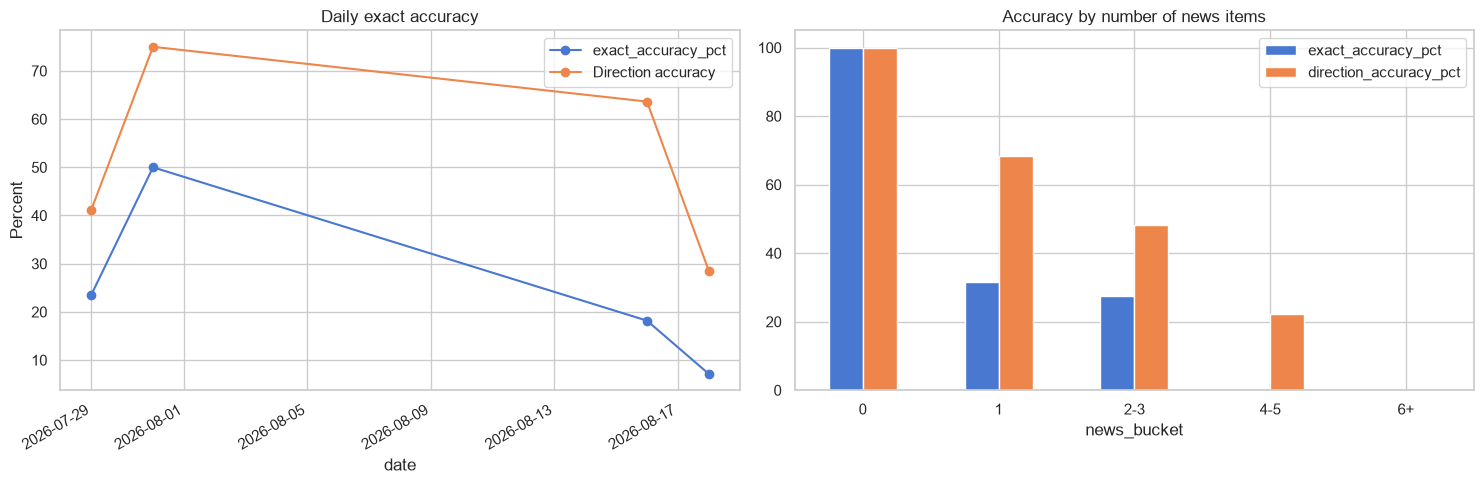

In [40]:
if not settled_df.empty:
    daily_live = settled_df.groupby('date').agg(
        n=('ticker', 'size'),
        exact_accuracy_pct=('correct', lambda s: s.mean() * 100),
        direction_accuracy_pct=('direction_correct', lambda s: s.mean() * 100),
        prediction_entropy_bits=('predicted_move_bin', lambda s: entropy_from_counts(s.value_counts().reindex(MOVE_BINS, fill_value=0))),
    ).sort_index()
    display(daily_live.round(3))

    news_bins = pd.cut(settled_df['num_news_items'], bins=[-1, 0, 1, 3, 5, np.inf], labels=['0', '1', '2-3', '4-5', '6+'])
    by_news = settled_df.assign(news_bucket=news_bins).groupby('news_bucket', observed=False).agg(
        n=('ticker', 'size'),
        exact_accuracy_pct=('correct', lambda s: s.mean() * 100),
        direction_accuracy_pct=('direction_correct', lambda s: s.mean() * 100),
        mean_actual_change_pct=('actual_change_1d', 'mean'),
    )
    display(by_news.round(3))

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    daily_live['exact_accuracy_pct'].plot(ax=axes[0], marker='o', title='Daily exact accuracy')
    daily_live['direction_accuracy_pct'].plot(ax=axes[0], marker='o', label='Direction accuracy')
    axes[0].set_ylabel('Percent'); axes[0].legend()
    by_news[['exact_accuracy_pct', 'direction_accuracy_pct']].plot(kind='bar', ax=axes[1], title='Accuracy by number of news items')
    axes[1].tick_params(axis='x', rotation=0)
    plt.tight_layout(); plt.show()
else:
    print('No settled live predictions are available yet.')

## 9. Review queue: largest misses

Use this table to inspect concrete failures. The most useful rows are large absolute returns with the wrong predicted direction, and class predictions that are several steps away from the actual class.

In [41]:
if not settled_df.empty:
    review_columns = [
        'logged_at', 'ticker', 'date', 'predicted_move_bin', 'actual_move_bin',
        'actual_change_1d', 'class_error_steps', 'num_news_items', 'base_price',
    ]
    review_df = settled_df[review_columns].copy()
    review_df['abs_actual_change_pct'] = review_df['actual_change_1d'].abs()
    print('Largest absolute-return misses:')
    display(review_df.sort_values(['abs_actual_change_pct', 'class_error_steps'], ascending=False).head(25))
    print('Largest class-distance misses:')
    display(review_df.sort_values(['class_error_steps', 'abs_actual_change_pct'], ascending=False).head(25))
else:
    print('No settled live predictions are available yet.')

Largest absolute-return misses:


,logged_at,ticker,date,predicted_move_bin,actual_move_bin,actual_change_1d,class_error_steps,num_news_items,base_price,abs_actual_change_pct
7,2026-07-31 06:35:23.262252+00:00,MSFT,2026-07-29,up,strong_up,15.5067,1,3,390.54,15.5067
1,2026-07-31 06:35:15.256372+00:00,AMD,2026-07-29,strong_down,strong_up,12.9970,4,4,429.56,12.9970
10,2026-07-31 06:35:27.041446+00:00,SOXX,2026-07-29,strong_down,strong_up,8.5011,4,1,465.00,8.5011
6,2026-07-31 06:35:22.009267+00:00,META,2026-07-29,flat,strong_down,-7.9541,2,4,585.61,7.9541
23,2026-08-01 00:50:57.773918+00:00,META,2026-07-31,strong_up,strong_up,6.0229,0,2,556.71,6.0229
29,2026-08-01 00:51:08.620839+00:00,USO,2026-07-31,strong_down,strong_down,-5.4579,0,2,129.17,5.4579
24,2026-08-01 00:50:59.834707+00:00,MSFT,2026-07-31,strong_up,strong_up,4.9342,0,1,464.72,4.9342
21,2026-08-01 00:50:53.927622+00:00,GOOGL,2026-07-31,strong_up,strong_up,4.8802,0,3,356.13,4.8802
19,2026-08-01 00:50:50.308324+00:00,AMZN,2026-07-31,strong_up,strong_up,4.5806,0,1,271.58,4.5806
4,2026-07-31 06:35:19.561103+00:00,DRIV,2026-07-29,strong_down,strong_up,4.5369,4,1,31.96,4.5369


Largest class-distance misses:


,logged_at,ticker,date,predicted_move_bin,actual_move_bin,actual_change_1d,class_error_steps,num_news_items,base_price,abs_actual_change_pct
1,2026-07-31 06:35:15.256372+00:00,AMD,2026-07-29,strong_down,strong_up,12.9970,4,4,429.56,12.9970
10,2026-07-31 06:35:27.041446+00:00,SOXX,2026-07-29,strong_down,strong_up,8.5011,4,1,465.00,8.5011
4,2026-07-31 06:35:19.561103+00:00,DRIV,2026-07-29,strong_down,strong_up,4.5369,4,1,31.96,4.5369
45,2026-08-19 16:00:04.543843+00:00,AMD,2026-08-18,strong_up,strong_down,-3.5343,4,2,484.39,3.5343
57,2026-08-19 16:00:20.531423+00:00,XLV,2026-08-18,down,strong_up,2.9459,3,3,169.73,2.9459
51,2026-08-19 16:00:12.545622+00:00,SOXX,2026-08-18,strong_up,down,-1.9176,3,2,531.39,1.9176
55,2026-08-19 16:00:17.978093+00:00,USO,2026-08-18,strong_down,up,1.6531,3,2,130.66,1.6531
13,2026-07-31 06:35:31.620776+00:00,USO,2026-07-29,strong_up,down,-1.4152,3,1,129.31,1.4152
6,2026-07-31 06:35:22.009267+00:00,META,2026-07-29,flat,strong_down,-7.9541,2,4,585.61,7.9541
2,2026-07-31 06:35:16.723955+00:00,AMZN,2026-07-29,flat,strong_up,3.9047,2,4,226.65,3.9047


## Interpretation checklist

- If train accuracy is high but validation accuracy is much lower, the model is overfitting.
- If validation accuracy is near its majority baseline and prediction mode share is high, the model may be using the dominant class rather than learning useful distinctions.
- Because validation guided early stopping and best-checkpoint selection, use a future chronological holdout or walk-forward evaluation for the final go/no-go decision.
- If exact accuracy is weak but direction accuracy is materially higher, the model may understand direction but not magnitude.
- If live accuracy varies sharply by ticker, inspect ticker-specific label balance, news coverage, and volatility before changing the model.
- If the live log has few settled rows, treat all conclusions as provisional.
- The training and validation files show labels, not model predictions. Generate deterministic predictions on both splits to measure actual train fit versus validation generalization.

## 10. LLM handoff summary

Run the next cell after refreshing the notebook. It creates a compact, copyable brief for an LLM. The brief separates training/validation evidence from settled production predictions and asks for concrete recommendations about data quality, label design, model behavior, and the next training experiments.

In [48]:
def fmt(value, digits=2):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return 'unavailable'
    if isinstance(value, (float, np.floating)):
        return f'{value:.{digits}f}'
    return str(value)

train_mode = train_df['label'].mode().iloc[0] if not train_df.empty else 'unavailable'
val_mode = val_df['label'].mode().iloc[0] if not val_df.empty else 'unavailable'
train_mode_share = train_df['label'].value_counts(normalize=True).iloc[0] * 100 if not train_df.empty else np.nan
val_mode_share = val_df['label'].value_counts(normalize=True).iloc[0] * 100 if not val_df.empty else np.nan

lines = []
lines.append('# FinCast Prediction Quality: LLM Review Brief')
lines.append('')
lines.append('## Objective')
lines.append('Assess whether the financial movement model is learning useful distinctions, whether it is dominated by class priors, how production predictions perform after outcomes settle, and what training/data changes should come next.')
lines.append('')
lines.append('## Data and evaluation definitions')
lines.append(f'- Training examples: {len(train_df):,}; validation examples: {len(val_df):,}.')
lines.append('- train.jsonl and val.jsonl contain labels used during model training and checkpoint selection; they do not contain model predictions.')
lines.append(f'- Production source: predictions_log.jsonl, latest row retained per ticker/date; settled rows require actual_move_bin.')
lines.append(f'- Settled production rows analyzed: {len(settled_df):,}.')
lines.append(f'- Five classes, ordered by severity: {MOVE_BINS}.')
lines.append('- Exact accuracy requires the full five-class label to match. Direction accuracy maps strong_down/down to down, flat to flat, and up/strong_up to up.')
lines.append('')
lines.append('## Label balance')
lines.append(f'- Training mode: {train_mode} ({fmt(train_mode_share)}% of training labels).')
lines.append(f'- Validation mode: {val_mode} ({fmt(val_mode_share)}% of validation labels).')
lines.append(f'- Training distribution: {train_dist["count"].to_dict()}.')
lines.append(f'- Validation distribution: {val_dist["count"].to_dict()}.')
lines.append('')
lines.append('## Validation interpretation')
lines.append('- Validation is a training-time model-selection signal because eval_loss, early stopping, and best-checkpoint selection use it.')
lines.append('- This notebook does not calculate validation accuracy because no validation model predictions are produced or expected.')
lines.append('- Compare train and validation label distributions for coverage and imbalance; use settled production predictions for actual prediction quality.')
lines.append('')
lines.append('## Settled production evidence')
if not settled_df.empty:
    lines.append(f'- Exact five-class accuracy: {fmt(settled_df["correct"].mean() * 100)}%.')
    lines.append(f'- Direction accuracy: {fmt(settled_df["direction_correct"].mean() * 100)}%.')
    lines.append(f'- Actual-majority baseline: {fmt(live_mode_accuracy * 100)}% ({live_mode}).')
    lines.append(f'- Lift over actual-majority baseline: {fmt((settled_df["correct"].mean() - live_mode_accuracy) * 100)} percentage points.')
    lines.append(f'- Production prediction mode: {settled_df["predicted_move_bin"].mode().iloc[0]} at {fmt(settled_df["predicted_move_bin"].value_counts(normalize=True).iloc[0] * 100)}%.')
    lines.append(f'- Mean class-distance error: {fmt(settled_df["class_error_steps"].mean())} ordered class steps.')
    lines.append(f'- Within one ordered class step: {fmt((settled_df["class_error_steps"] <= 1).mean() * 100)}%.')
else:
    lines.append('- No settled production rows are available.')
lines.append('')
lines.append('## Per-ticker production snapshot')
if not settled_df.empty:
    for ticker, row in ticker_live.sort_values('exact_accuracy_pct', ascending=False).iterrows():
        lines.append(f'- {ticker}: n={int(row["n"])}, exact={fmt(row["exact_accuracy_pct"])}%, direction={fmt(row["direction_accuracy_pct"])}%, prediction_mode={row["prediction_mode"]} ({fmt(row["prediction_mode_share_pct"])}%), actual_return_mean={fmt(row["mean_actual_change_pct"])}%, actual_return_std={fmt(row["std_actual_change_pct"])}%.')
else:
    lines.append('- Unavailable.')
lines.append('')
lines.append('## Important interpretation cautions')
lines.append('- Production rows are a time series and may be correlated; do not treat each row as fully independent.')
lines.append('- The current production sample may be small and class balance can change as more days settle.')
lines.append('- A model can have weak exact accuracy but useful directional accuracy, or good accuracy only because of a dominant class.')
lines.append('- Train-versus-validation label agreement does not prove the model learned; it only checks dataset comparability.')
lines.append('')
lines.append('## Questions for the reviewing LLM')
lines.append('1. Does the evidence indicate class collapse, label imbalance, magnitude confusion, ticker-specific failure, or data leakage/duplication?')
lines.append('2. Is exact five-class movement prediction an appropriate objective for this sample size and volatility regime?')
lines.append('3. Should labels be rebalanced, volatility-normalized, downsampled, or changed to directional classification first?')
lines.append('4. What data-quality checks should be performed on news relevance, duplicate stories, dates, price alignment, weekend rows, and target construction?')
lines.append('5. What is the smallest rigorous experiment plan to compare the current model against majority, ticker-majority, directional, and simpler statistical baselines?')
lines.append('6. What additional chronological production data should be collected before trusting improvements?')
lines.append('7. Recommend the next three training experiments, each with a hypothesis, exact dataset change, metric, and pass/fail criterion.')

llm_handoff = '\n'.join(lines)
print(llm_handoff)
HANDOFF_PATH = BASE_DIR / 'analysis' / 'prediction_quality_llm_handoff.txt'
HANDOFF_PATH.parent.mkdir(parents=True, exist_ok=True)
HANDOFF_PATH.write_text(llm_handoff, encoding='utf-8')
print(f'\nSaved copyable brief to: {HANDOFF_PATH}')

# FinCast Prediction Quality: LLM Review Brief

## Objective
Assess whether the financial movement model is learning useful distinctions, whether it is dominated by class priors, how production predictions perform after outcomes settle, and what training/data changes should come next.

## Data and evaluation definitions
- Training examples: 1,068; validation examples: 157.
- train.jsonl and val.jsonl contain labels used during model training and checkpoint selection; they do not contain model predictions.
- Production source: predictions_log.jsonl, latest row retained per ticker/date; settled rows require actual_move_bin.
- Settled production rows analyzed: 58.
- Five classes, ordered by severity: ['strong_down', 'down', 'flat', 'up', 'strong_up'].
- Exact accuracy requires the full five-class label to match. Direction accuracy maps strong_down/down to down, flat to flat, and up/strong_up to up.

## Label balance
- Training mode: flat (27.62% of training labels).
- Validation mode: fla